# Declaration of Originality

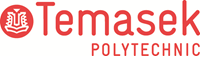

**TEMASEK POLYTECHNIC**
<br>**SCHOOL OF INFORMATICS & IT**
<br>**DIPLOMA IN INFORMATION TECHNOLOGY**
<br>**MACHINE LEARNING FOR DEVELOPERS (CAI2C08)**
<br>**AY2025/2026 OCTOBER SEMESTER**

**PROJECT PROGRAM CODES**
* Student Name (Matric Number)  :
* Tutorial Group                :  
* Tutor						    :  
* Submission Date               : 


**Declaration of Originality**
* I am the originator of this work and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [5]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

# 1. Business Understanding

# Stroke Prediction Project

## Problem Definition

Stroke is one of the leading causes of death and long-term disability globally, posing a significant burden on healthcare systems and affecting millions of lives each year. Early identification of individuals at high risk is critical, as timely intervention can prevent severe outcomes, reduce treatment costs, and improve patient quality of life. Despite this, many people remain unaware of their risk until a stroke occurs, highlighting a need for proactive, data-driven solutions in healthcare.

The specific challenge addressed in this project is to predict the likelihood of stroke for an individual based on structured patient data, including demographic information, lifestyle factors, and existing medical conditions. Key factors such as age, gender, hypertension, heart disease, body mass index (BMI), average glucose level, and smoking status can significantly influence stroke risk. By analyzing these features collectively, a predictive model can assist healthcare providers in identifying high-risk patients before critical events occur, enabling preventive care and personalized health interventions.

## Machine Learning Task

The task is framed as a **supervised learning problem**, specifically a **binary classification task**, where the goal is to predict whether a patient will experience a stroke (`1`) or not (`0`). The dataset contains structured tabular data with multiple feature types: numeric features like age, BMI, and average glucose level; categorical features like gender, work type, smoking status, and residential area; and binary features such as the presence of hypertension or heart disease.

Given the dataset is labeled, supervised learning models such as **Logistic Regression, Random Forest, and Gradient Boosting classifiers** can be trained to learn patterns that differentiate patients at risk from those who are not. Particular attention is given to handling **class imbalance**, as stroke occurrences are relatively rare compared to non-stroke cases, and to selecting evaluation metrics like **recall, F1-score, and ROC-AUC** to ensure the model effectively identifies high-risk patients.

## Business Impact / Value Proposition

The proposed solution has significant potential impact both for healthcare providers and patients. Hospitals and clinics can use the model to prioritize monitoring and preventive care for high-risk individuals, optimizing resource allocation and reducing the number of severe stroke incidents. Early detection allows for timely interventions, such as lifestyle counseling, medication adjustments, or routine monitoring, ultimately reducing long-term treatment costs and improving patient outcomes.

For patients, this predictive tool provides awareness of personal risk, empowering them to make informed decisions regarding lifestyle changes or medical follow-up. From a business perspective, the solution can be scaled as a **health-tech product integrated into hospital management systems, mobile health applications, or insurance platforms**, offering quantifiable benefits such as reduced hospitalization costs, improved patient care metrics, and enhanced preventative healthcare services. In essence, the model transforms raw patient data into actionable insights, creating a tangible value proposition for both healthcare providers and end-users.



# 2. Data Understanding

## 2.1 Load dataset

In [6]:
## Read *.csv file into pandas DataFrame
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


## 2.2 Summary Statistics

In [7]:
## Understand the type of variable for each column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [8]:
## Check for missing data
df.isna().sum()


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [9]:
## Describe data distribution
df.describe(include = 'all')

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


### Explanation

To understand the Stroke Prediction dataset, I used df.info() to display the summary information about the DataFrame. It shows the number of rows and columns, column names, data types (int64, float64, object) and number of non-missing values in each column. It is important for the data set as it helps to identify numeric vs categorical features. it also spots missing data quick and ensures data is correctly formatted.

df.isna().sum() is used to count the missign values in each column. It is importanf as missing values can break ML models and reduce performance if not handled. When I run the code, there are no missing values for the columns other than 201 missing values in bmi.

df.describe(include='all') is used to provides the statistics for each column. It helps to understand data distribution and ranges. it also reveals outliers and helps guide feature engineering.


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

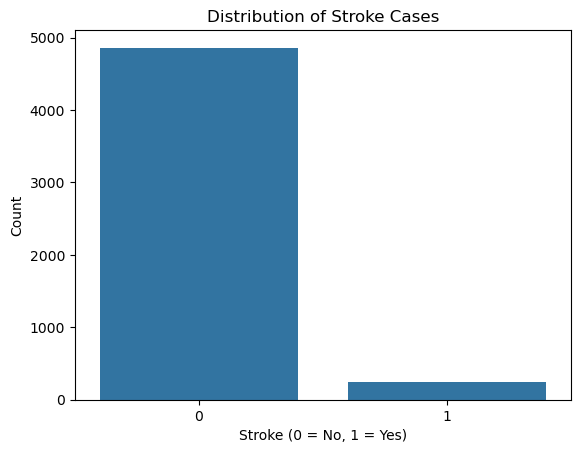

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [10]:
# Countplot for target variable
sns.countplot(x='stroke', data=df)
plt.title('Distribution of Stroke Cases')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Percentage distribution of stroke cases
stroke_counts = df['stroke'].value_counts(normalize=True) * 100
print(stroke_counts)


#### Explaination
This diagram visualized the distribution of the target variable 'stroke'. Most patients (95%) did not have a stroke, while only (5%) had a stroke, indicating class imbalance.

### 2.3.1.2 Understanding distribution of features

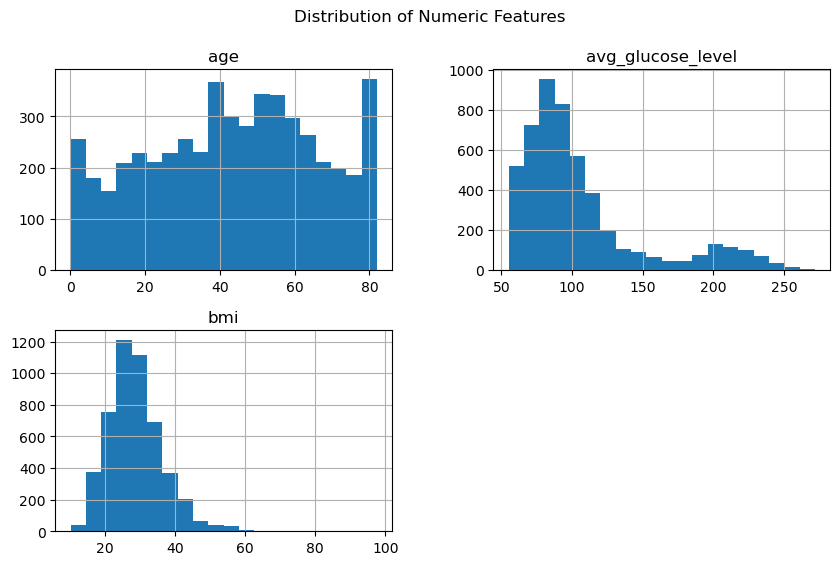

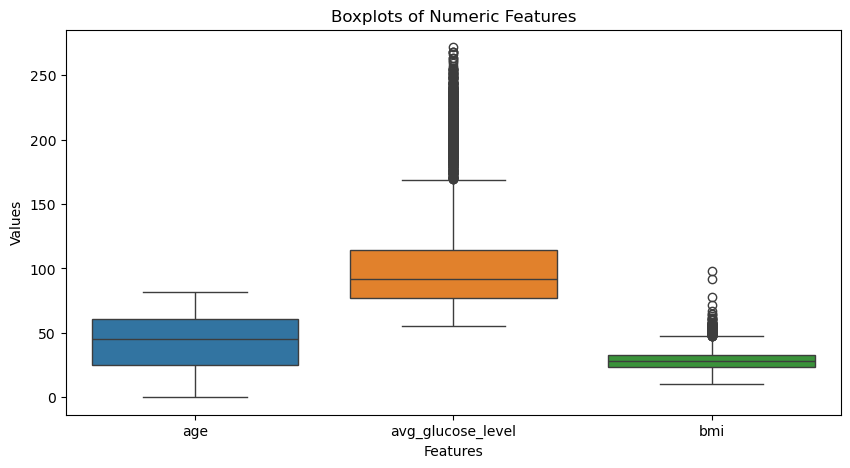

In [11]:
## Understanding distribution of features
numeric_features = ['age', 'avg_glucose_level', 'bmi']

df[numeric_features].hist(bins=20, figsize=(10,6))
plt.suptitle('Distribution of Numeric Features')
plt.show()

## Check for outliers

plt.figure(figsize=(10, 5))
sns.boxplot(data=df[numeric_features])
plt.title('Boxplots of Numeric Features')
plt.xlabel('Features')
plt.ylabel('Values')
plt.show()



#### Explaination
I analyzed the distributions of both numeric and categorical features. For numeric features, histograms revealed the ranges and outliers in age, bmi, and avg_glucose_level.

A combined boxplot was used to visualize potential outliers accross numeric features, including age, BMI, and average glucose level. the plot shows rhat while age has a relatively stable distributions, BMI and glucose levels contain some extreme values. These values are considered medically valid and may represent gigh-risk individuals, therefore, no outliers were removed to preserve important clinical information for stroke prediction.

### 2.3.2 Understanding relationship between variables

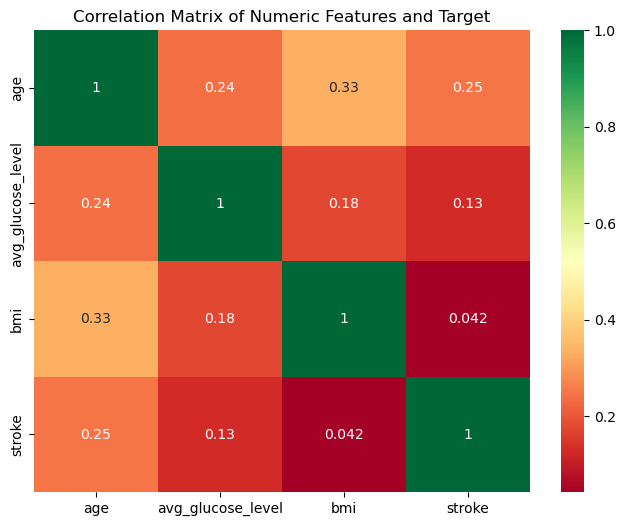

In [12]:
## Understanding relationship between variables
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_features + ['stroke']].corr(), annot=True, cmap='RdYlGn')
plt.title('Correlation Matrix of Numeric Features and Target')
plt.show()



# 3. Data Preparation

## 3.1 Data Cleaning

In [13]:
## Clean data
# Drop ID column (not useful for prediction)
df = df.drop(columns=['id'])

# Fill missing BMI values using median
df['bmi'].fillna(df['bmi'].median(), inplace=True)

# Encode categorical variables using one-hot encoding
df = pd.get_dummies(
    df,
    columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'],
    drop_first=True
)

# Check final dataset
df.isna().sum()


C:\Users\trick\AppData\Local\Temp\ipykernel_22032\1022947675.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)


age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
stroke                            0
gender_Male                       0
gender_Other                      0
ever_married_Yes                  0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Urban              0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64

#### Explaination

Data cleaning is a critical step to ensure the dataset is suitable for machine learning models.

First the id column was removed because it is a unique identifier and does no contain predictive information relevant to stroke risk. Including such identifiers may introduce noise into the model.

Next, the missing values were handled as the bmi column contained 201 missing values. BMI values imputed using the median, which is robust to outliers and preserves the overall distribution of the data.

Finally, categorical variables such as a gender, work type, and soming status where converted into numerical format using one-hot encoding. this step is necessary because machine learning modules in scikit-learn require numerical inputs. The drop_first=True option was used to prevent multicollinearity

## 3.2 Train-Test Split

In [14]:
## Split data into train set and test set

from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['stroke'])
y = df['stroke']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2026,
)

# Check shapes
print(X_train.shape, X_test.shape)


(4088, 16) (1022, 16)


#### Explaination
After cleaning the data, the dataset was split into training and testing sets evaluate the model's performance on unseen data.

The features (X) consist of all predixtor variavles. while target (y) is the binary stroke outcome. The dataset was split using an 80/20 ratio, where 80% of the data is used to train the model and 20% is reserved for testing.

A fixed random_state was set to ensure reproductibility or results.

# 4. Modelling

### 4.2 Train Model

In [15]:
## Initialise and train model
from sklearn.linear_model import LogisticRegression

# Initialize the model
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=2026
)

# Train the model
lr_model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,2026
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
from sklearn.ensemble import RandomForestClassifier

# Initialise the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=2026
)

# Train the model
rf_model.fit(X_train, y_train)




,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialise the model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=2026
)

# Train the model
gb_model.fit(X_train, y_train)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


#### Explaination
After splitting the dataset into training and testing sets, a Logistic Regression model was selected as the baseline classifier for stroke prediction. Logistic Regression is a supervised learning algorithm commonly used for binary classification problems, making it suitable for this task where the target variable indicates whether a patient has experienced a stroke or not.

The model learns the relationship between the input features (such as age, BMI, hypertension status, and average glucose level) and the probability of stroke occurrence. By estimating these probabilities, the model is able to classify individuals into stroke and non-stroke categories.

The parameter max_iter=1000 was specified to ensure that the optimisation process converges during training. Since the dataset is imbalanced with significantly fewer stroke cases compared to non-stroke cases, the parameter class_weight='balanced' was applied to give more importance to the minority class. This helps improve the model’s ability to correctly identify stroke patients, which is critical in healthcare applications.

Logistic Regression was chosen as the baseline model due to its simplicity, efficiency, and interpretability. In healthcare-related applications, interpretability is particularly important as it allows stakeholders to understand how input features contribute to the prediction, making the model suitable as a starting point for comparison with more complex models.


# 5. Model Evaluation

In [18]:
# ================================
# MODEL EVALUATION
# ================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# --------------------------------
# Logistic Regression Evaluation
# --------------------------------
y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("----------------------------")
print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1-score  : {lr_f1:.4f}")

cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion Matrix:")
print(cm_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


# --------------------------------
# Random Forest Evaluation
# --------------------------------
y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("\nRandom Forest Results")
print("---------------------")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-score  : {rf_f1:.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(cm_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


# --------------------------------
# Gradient Boosting Evaluation
# --------------------------------
y_pred_gb = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)

print("\nGradient Boosting Results")
print("-------------------------")
print(f"Accuracy  : {gb_accuracy:.4f}")
print(f"Precision : {gb_precision:.4f}")
print(f"Recall    : {gb_recall:.4f}")
print(f"F1-score  : {gb_f1:.4f}")

cm_gb = confusion_matrix(y_test, y_pred_gb)
print("\nConfusion Matrix:")
print(cm_gb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))


Logistic Regression Results
----------------------------
Accuracy  : 0.7329
Precision : 0.1516
Recall    : 0.8246
F1-score  : 0.2561

Confusion Matrix:
[[702 263]
 [ 10  47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.73      0.84       965
           1       0.15      0.82      0.26        57

    accuracy                           0.73      1022
   macro avg       0.57      0.78      0.55      1022
weighted avg       0.94      0.73      0.80      1022


Random Forest Results
---------------------
Accuracy  : 0.9423
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000

Confusion Matrix:
[[963   2]
 [ 57   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       965
           1       0.00      0.00      0.00        57

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.49      1022
weighted avg   

#### Explaination
The trained Logistic Regression model was evaluated using the test dataset, which contains data not seen during training. Multiple evaluation metrics were used to assess model performance comprehensively.

- Accuracy measures the overall correctness of predictions.
- Precision indicates how many predicted stroke cases were actually strokes
- Recall measures model's ability correctly identify stroke patients.
- F1-score balances precision and recall and is especially useful for imbalanced datasets like stroke prediction
- Confusion matrix provides insight into false positives and false negatives.

Recall is particularly important in this problem because failing to detect a stroke patient may have sever health consequences.

In [19]:
## New data

## Predict


## Iterative model development


In [20]:
## Further feature engineering / feature selection